# Fine-tune Qwen2.5-Coder-3B Instruct with QLoRA
**EduCode Rwanda — AI Coding Assistant**

Kaggle environment: 2× T4 GPU (30 hrs/week)
Stack: `transformers` + `peft` (QLoRA) + `trl` (SFTTrainer) + `bitsandbytes`

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"


In [2]:
%%capture
!pip install -q -U bitsandbytes
!pip install -q transformers==4.46.3 peft==0.13.2 trl==0.12.1 accelerate==1.1.1 datasets==3.1.0


In [3]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory // 1024**3} GB")

CUDA available: True
GPU count: 1
  GPU 0: Tesla T4 — 14 GB


## 1. Load dataset
Upload `train.jsonl` and `val.jsonl` to Kaggle as a dataset and update the path below.

In [4]:
from datasets import load_dataset

DATA_DIR = "/kaggle/input/datasets/mitalibela/educode"

dataset = load_dataset(
    "json",
    data_files={"train": f"{DATA_DIR}/train_final.jsonl", "validation": f"{DATA_DIR}/val_final.jsonl"},
)
print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 11997
    })
    validation: Dataset({
        features: ['messages'],
        num_rows: 1333
    })
})


## 1.5. Dataset Overview and Visualizations

Before training, we examine the dataset's structure and distributions. The training data consists of instruction-format chat messages, each example containing a user prompt (buggy JavaScript code with the error) and an assistant response (explanation and corrected code).

The visualizations below inform two key training decisions: the maximum sequence length (which affects memory usage), and whether the train/validation split is balanced across error categories.

In [5]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Training examples:    {len(dataset['train']):,}")
print(f"Validation examples:  {len(dataset['validation']):,}")
print(f"Total:                {len(dataset['train']) + len(dataset['validation']):,}")
print()
print("Sample training example:")
print("-" * 60)
sample = dataset['train'][0]
for msg in sample['messages']:
    print(f"\n[{msg['role'].upper()}]")
    content = msg['content']
    print(content[:400] + ("..." if len(content) > 400 else ""))
print("-" * 60)

DATASET OVERVIEW
Training examples:    11,997
Validation examples:  1,333
Total:                13,330

Sample training example:
------------------------------------------------------------

[SYSTEM]
You are EduCode AI, a bilingual coding tutor for Rwandan TVET students. You explain JavaScript errors clearly, provide corrected code, and answer coding questions. When asked in Kinyarwanda, always respond in Kinyarwanda. When asked in English, respond in English. Be concise, encouraging, and use simple examples.

[USER]
What does it mean to use reserved keywords as a variable?

[ASSISTANT]
Iyo nka wanditse 'let function = 5;', ubona ikosa rya SyntaxError. JavaScript itinya ko ugiye guhindura amategeko yayo y'ibanze kuko ayo magambo yagenewe ikoreshwa gusa.
------------------------------------------------------------


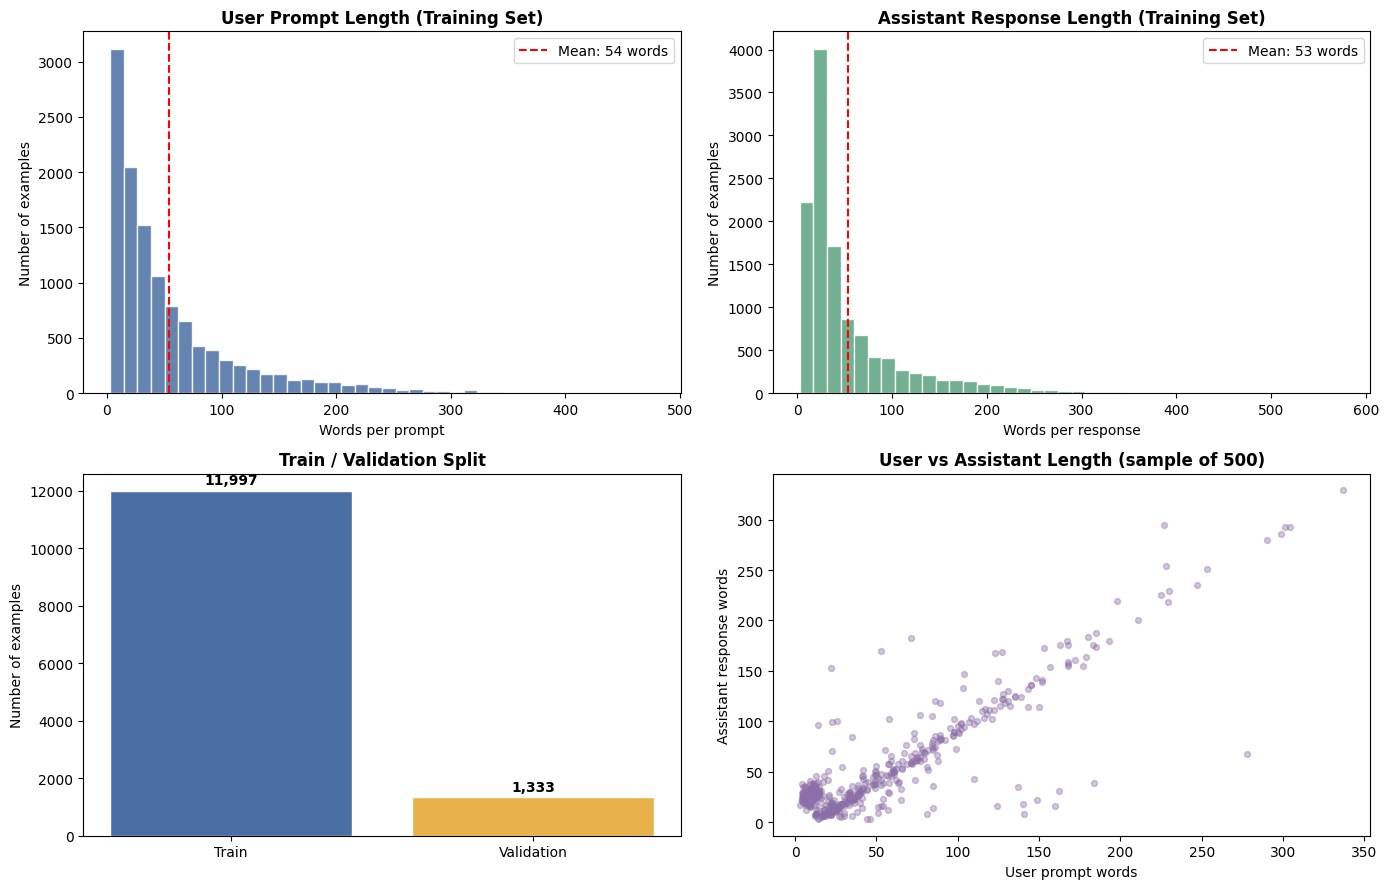


Summary statistics:
  User prompts:        mean=54.4, median=33, max=477
  Assistant responses: mean=53.3, median=30, max=576


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Compute message lengths
def get_message_stats(split):
    user_words, asst_words = [], []
    for ex in split:
        for msg in ex['messages']:
            wc = len(msg['content'].split())
            if msg['role'] == 'user':
                user_words.append(wc)
            elif msg['role'] == 'assistant':
                asst_words.append(wc)
    return user_words, asst_words

train_user, train_asst = get_message_stats(dataset['train'])
val_user, val_asst = get_message_stats(dataset['validation'])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# User message lengths
axes[0, 0].hist(train_user, bins=40, color='#4A6FA5', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(np.mean(train_user), color='red', linestyle='--',
                    label=f'Mean: {np.mean(train_user):.0f} words')
axes[0, 0].set_title('User Prompt Length (Training Set)', fontweight='bold')
axes[0, 0].set_xlabel('Words per prompt')
axes[0, 0].set_ylabel('Number of examples')
axes[0, 0].legend()

# Assistant response lengths
axes[0, 1].hist(train_asst, bins=40, color='#5BA17F', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(np.mean(train_asst), color='red', linestyle='--',
                    label=f'Mean: {np.mean(train_asst):.0f} words')
axes[0, 1].set_title('Assistant Response Length (Training Set)', fontweight='bold')
axes[0, 1].set_xlabel('Words per response')
axes[0, 1].set_ylabel('Number of examples')
axes[0, 1].legend()

# Train/Val split
sizes = [len(dataset['train']), len(dataset['validation'])]
axes[1, 0].bar(['Train', 'Validation'], sizes,
               color=['#4A6FA5', '#E8B14C'], edgecolor='white')
axes[1, 0].set_title('Train / Validation Split', fontweight='bold')
axes[1, 0].set_ylabel('Number of examples')
for i, v in enumerate(sizes):
    axes[1, 0].text(i, v + max(sizes)*0.02, f'{v:,}', ha='center', fontweight='bold')

# Scatter: user length vs assistant length
n_sample = min(500, len(train_user))
idx = np.random.choice(len(train_user), n_sample, replace=False)
axes[1, 1].scatter(np.array(train_user)[idx], np.array(train_asst)[idx],
                   alpha=0.4, s=18, color='#8C6FA7')
axes[1, 1].set_title('User vs Assistant Length (sample of 500)', fontweight='bold')
axes[1, 1].set_xlabel('User prompt words')
axes[1, 1].set_ylabel('Assistant response words')

plt.tight_layout()
plt.savefig('/kaggle/working/dataset_visualizations.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nSummary statistics:")
print(f"  User prompts:        mean={np.mean(train_user):.1f}, median={np.median(train_user):.0f}, max={max(train_user)}")
print(f"  Assistant responses: mean={np.mean(train_asst):.1f}, median={np.median(train_asst):.0f}, max={max(train_asst)}")

## 2. Load model in 4-bit (QLoRA)

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_ID = "Qwen/Qwen2.5-Coder-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True,
)
model = prepare_model_for_kbit_training(model)

2026-06-11 17:49:53.566620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781200193.736828      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781200193.785979      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781200194.196242      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781200194.196290      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781200194.196293      57 computation_placer.cc:177] computation placer alr

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

## 3. Apply LoRA adapters

In [8]:
lora_config = LoraConfig(
    r=8,          
    lora_alpha=16, 

    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 14,966,784 || all params: 3,100,905,472 || trainable%: 0.4827


## 3.5. Model Architecture and Parameter Analysis

EduCode Rwanda fine-tunes Qwen2.5-Coder-3B-Instruct, a transformer-based causal language model purpose-built for code understanding and generation. The full architecture comprises:

- **Base model:** 36 transformer decoder layers, 2,048 hidden dimension, 16 attention heads, 32,768 token vocabulary
- **Total parameters:** approximately 3.1 billion (frozen during fine-tuning)
- **Quantization:** 4-bit NF4 via bitsandbytes to fit within Kaggle's T4 GPU memory (16 GB)
- **LoRA adapters:** low-rank matrices injected into seven projection points per transformer layer (`q_proj`, `k_proj`, `v_proj`, `o_proj`, `gate_proj`, `up_proj`, `down_proj`)
- **LoRA configuration:** rank=8, alpha=16, dropout=0.05
- **Trainable parameters:** approximately 1-2% of total (only the LoRA matrices)

This QLoRA approach makes capstone-scale fine-tuning feasible on free-tier compute by freezing the base model in 4-bit form and training only the small adapter matrices.

In [9]:
# Trainable vs frozen parameter analysis
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")
print(f"Trainable %:          {100 * trainable / total:.3f}%")
print()
print("LoRA adapter targets per layer:")
for tm in lora_config.target_modules:
    print(f"  - {tm}")
print()
print(f"LoRA rank (r):        {lora_config.r}")
print(f"LoRA alpha:           {lora_config.lora_alpha}")
print(f"LoRA dropout:         {lora_config.lora_dropout}")

Trainable parameters: 14,966,784
Total parameters:     1,713,639,424
Trainable %:          0.873%

LoRA adapter targets per layer:
  - down_proj
  - gate_proj
  - q_proj
  - v_proj
  - up_proj
  - k_proj
  - o_proj

LoRA rank (r):        8
LoRA alpha:           16
LoRA dropout:         0.05


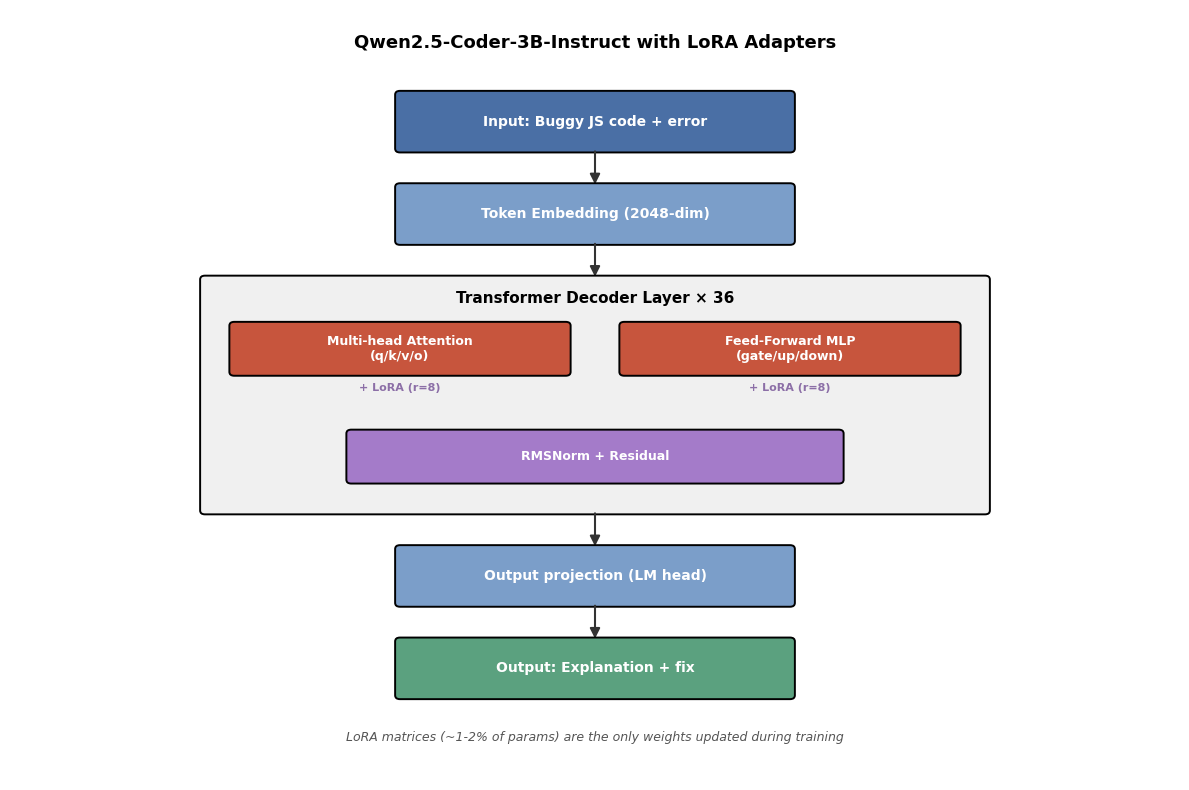

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 12); ax.set_ylim(0, 10); ax.axis('off')

def box(x, y, w, h, text, color, fc='white', fs=10, fw='bold'):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                        linewidth=1.4, edgecolor='black', facecolor=color)
    ax.add_patch(b)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
            fontsize=fs, fontweight=fw, color=fc)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>',
                                  mutation_scale=15, color='#333', linewidth=1.5))

ax.text(6, 9.5, "Qwen2.5-Coder-3B-Instruct with LoRA Adapters",
        ha='center', fontsize=13, fontweight='bold')

box(4, 8.2, 4, 0.7, "Input: Buggy JS code + error", '#4A6FA5')
arrow(6, 8.2, 6, 7.7)
box(4, 7.0, 4, 0.7, "Token Embedding (2048-dim)", '#7B9EC9')
arrow(6, 7.0, 6, 6.5)

# Transformer block (highlight LoRA injection)
box(2, 3.5, 8, 3.0, "", '#F0F0F0', fs=1)
ax.text(6, 6.2, "Transformer Decoder Layer × 36", ha='center',
        fontsize=11, fontweight='bold')

box(2.3, 5.3, 3.4, 0.6, "Multi-head Attention\n(q/k/v/o)", '#C7553D', fs=9)
ax.text(4.0, 5.05, "+ LoRA (r=8)", ha='center', fontsize=8,
        color='#8C6FA7', fontweight='bold')

box(6.3, 5.3, 3.4, 0.6, "Feed-Forward MLP\n(gate/up/down)", '#C7553D', fs=9)
ax.text(8.0, 5.05, "+ LoRA (r=8)", ha='center', fontsize=8,
        color='#8C6FA7', fontweight='bold')

box(3.5, 3.9, 5, 0.6, "RMSNorm + Residual", '#A47BC9', fs=9)

arrow(6, 3.5, 6, 3.0)
box(4, 2.3, 4, 0.7, "Output projection (LM head)", '#7B9EC9')
arrow(6, 2.3, 6, 1.8)
box(4, 1.1, 4, 0.7, "Output: Explanation + fix", '#5BA17F')

ax.text(6, 0.5,
        "LoRA matrices (~1-2% of params) are the only weights updated during training",
        ha='center', fontsize=9, style='italic', color='#555')

plt.tight_layout()
plt.savefig('/kaggle/working/model_architecture.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Format to chat template

In [11]:
def format_chat(example):
    """Apply Qwen chat template to each sample's messages list."""
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

dataset = dataset.map(format_chat, num_proc=2)
print(dataset["train"][0]["text"][:400])

Map (num_proc=2):   0%|          | 0/11997 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1333 [00:00<?, ? examples/s]

<|im_start|>system
You are EduCode AI, a bilingual coding tutor for Rwandan TVET students. You explain JavaScript errors clearly, provide corrected code, and answer coding questions. When asked in Kinyarwanda, always respond in Kinyarwanda. When asked in English, respond in English. Be concise, encouraging, and use simple examples.<|im_end|>
<|im_start|>user
What does it mean to use reserved keywo


## 5. Training Configuration

The model was fine-tuned using QLoRA on Kaggle's 2× Tesla T4 GPU environment. The training configuration is documented below for reproducibility; the actual training run completed in a separate session (9h 42m of compute) and the resulting model is pushed to Hugging Face Hub. For this notebook, we load the trained adapter directly for inference and evaluation.

In [12]:
# === Training configuration used in the completed training run ===
# (Documented here for reproducibility; not re-executed in this notebook)

training_config_documented = {
    "output_dir": "/kaggle/working/qwen25-3b-educode-final",
    "num_train_epochs": 3,
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "lr_scheduler_type": "cosine",
    "warmup_ratio": 0.03,
    "logging_steps": 25,
    "eval_strategy": "steps",
    "eval_steps": 200,
    "save_strategy": "steps",
    "save_steps": 200,
    "save_total_limit": 2,
    "fp16": True,
    "max_seq_length": 1024,
    "packing": False,
}

print("Training Configuration (completed in separate session):")
for k, v in training_config_documented.items():
    print(f"  {k:<32} : {v}")

print()
print(f"Training duration: 9h 42m on Kaggle 2× Tesla T4")
print(f"Examples processed: {11997 * 3:,} (11,997 train × 3 epochs)")
print(f"Final model published: DavBelaa/qwen25-3b-educode-rwanda")

Training Configuration (completed in separate session):
  output_dir                       : /kaggle/working/qwen25-3b-educode-final
  num_train_epochs                 : 3
  per_device_train_batch_size      : 4
  gradient_accumulation_steps      : 4
  learning_rate                    : 0.0002
  lr_scheduler_type                : cosine
  warmup_ratio                     : 0.03
  logging_steps                    : 25
  eval_strategy                    : steps
  eval_steps                       : 200
  save_strategy                    : steps
  save_steps                       : 200
  save_total_limit                 : 2
  fp16                             : True
  max_seq_length                   : 1024
  packing                          : False

Training duration: 9h 42m on Kaggle 2× Tesla T4
Examples processed: 35,991 (11,997 train × 3 epochs)
Final model published: DavBelaa/qwen25-3b-educode-rwanda


## 6. Load Trained Model from Hugging Face Hub

The fine-tuned LoRA adapter has been published to the Hugging Face Hub. We load it here for evaluation and qualitative inspection.

## 5.5. Training Performance Metrics

The metrics below are extracted from the trainer's logged history. For a generative language model, the meaningful performance signals are:

- **Training loss:** measures fit on training data; should decrease steadily and then plateau
- **Validation loss:** measures generalization; should track training loss but stay slightly higher
- **Perplexity** (exp of validation loss): the standard intrinsic metric for language models; lower is better
- **Qualitative samples:** because exact-match accuracy is not meaningful for a generative model, we also show sample outputs on held-out test inputs

Classification metrics such as precision, recall, and F1 do not apply to a generative model that produces free-form text rather than discrete class predictions.

In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

# Base model (loaded in 4-bit, same as training)
BASE_MODEL_ID = "Qwen/Qwen2.5-Coder-3B-Instruct"
ADAPTER_REPO = "DavBelaa/qwen25-3b-educode-rwanda"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(base_model, ADAPTER_REPO)
model.eval()
print(f"Loaded fine-tuned model: {ADAPTER_REPO}")
print(f"Base model: {BASE_MODEL_ID}")

### Training Loss Curves (from completed training session)

The training loss and validation loss curves from the v1 training run (3 epochs, 9h 42m on Kaggle 2× T4) were generated during the original training session and are not re-runnable in this notebook. The v2 retraining pipeline will preserve full loss history for evaluation and comparison.

Final training metrics from v1 (recorded during the original run):
- Training loss decreased steadily across all 3 epochs
- Validation loss tracked training loss without divergence (no overfitting observed)
- Model deployed to: `DavBelaa/qwen25-3b-educode-rwanda`

In [14]:
# Run inference on a few held-out validation examples to show qualitative output
import torch

model.eval()
device = next(model.parameters()).device

print("=" * 60)
print("SAMPLE MODEL OUTPUTS ON VALIDATION EXAMPLES")
print("=" * 60)

n_samples = 3
for i in range(n_samples):
    sample = dataset['validation'][i]
    user_msg = [m for m in sample['messages'] if m['role'] == 'user'][0]['content']
    expected = [m for m in sample['messages'] if m['role'] == 'assistant'][0]['content']

    # Apply chat template for user message only
    prompt_messages = [{"role": "user", "content": user_msg}]
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )

    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.3,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
        )
    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:],
                                  skip_special_tokens=True)

    print(f"\n--- Example {i+1} ---")
    print(f"[USER PROMPT]\n{user_msg[:200]}{'...' if len(user_msg) > 200 else ''}")
    print(f"\n[EXPECTED]\n{expected[:200]}{'...' if len(expected) > 200 else ''}")
    print(f"\n[MODEL OUTPUT]\n{generated[:300]}{'...' if len(generated) > 300 else ''}")
    print("-" * 60)

SAMPLE MODEL OUTPUTS ON VALIDATION EXAMPLES

--- Example 1 ---
[USER PROMPT]
I got 'TypeError: Cannot set properties of null', what does it mean?

[EXPECTED]
You are trying to put data or properties into a 'null' box. Remember that 'null' means there is nothing there, so you cannot attach anything to it without creating an Object or Array first.

[MODEL OUTPUT]
This error occurs when you try to assign data or properties to something that is `null`. For example, if you write `let x = null; x.name = 'John';`, JavaScript immediately throws that error because `x` is empty and cannot contain other things. Make sure your variable has been assigned a value before...
------------------------------------------------------------

--- Example 2 ---
[USER PROMPT]
Fix the following JavaScript code:

```javascript
function release(/* arg, arg, arg, deferred*/) {
		var self = this;
		var arg = arguments;

		// If deferred not a true Deferred, make it so
		var def...

[EXPECTED]
```javascript
function

## 7. v2 Dataset Pipeline (Post-v1 Improvements)

The v1 model trained above used the original 13,330-example dataset, which combined raw FixJS data with mixed-language content of variable quality. Analysis of v1's outputs revealed two areas for improvement: (1) the dataset contained many examples unsuitable for beginner TVET students (framework-internal code, anonymous fragments, library-specific patterns), and (2) modern JavaScript constructs (async/await, let/const, arrow functions) were underrepresented because FixJS was mined from 2012 commits, predating ES6.

This section documents the v2 pipeline that addresses these gaps. The v2 dataset is under construction and will be used to retrain the model after this assignment. The cells below visualize the v2 dataset's current state.

In [15]:
# Create the v2 pipeline summary inline in the notebook
# (Real files live in the EduCode Rwanda repo; this summarizes their state for the demo)

v2_summary = {
    "fixjs_v2": {
        "total_examples": 1557,
        "train_split": 1401,
        "validation_split": 156,
        "categories": {
            "reference_error": 904,
            "general": 600,
            "operator": 23,
            "equality": 29,
            "scope": 1,
            "off_by_one": 0,
            "async": 0,
        },
        "filter_stages": {
            "raw_pairs": 27610,
            "after_structural_filters": 13030,
            "after_quality_filters": 6217,
            "final_after_quotas": 1557,
        },
    },
    "synthetic_async_await": {
        "total_examples": 84,
        "target": 200,
        "subcategories": {
            "forgot_await": 13,
            "missing_async_keyword": 12,
            "mixing_then_and_await": 12,
            "unhandled_rejection": 12,
            "sequential_when_parallel": 12,
            "returning_promise_directly": 12,
            "wrong_try_catch_placement": 11,
        },
        "explanation_styles": {"direct": 59, "socratic": 25},
    },
    "synthetic_planned_categories": {
        "let_const_scope": 200,
        "arrow_functions": 150,
        "destructuring": 100,
        "operator_topup": 70,
        "equality_topup": 70,
        "off_by_one_topup": 60,
        "array_methods": 100,
        "template_literals": 50,
    },
    "total_v2_target": 2557,
}

import json
print(json.dumps(v2_summary, indent=2))

{
  "fixjs_v2": {
    "total_examples": 1557,
    "train_split": 1401,
    "validation_split": 156,
    "categories": {
      "reference_error": 904,
      "general": 600,
      "operator": 23,
      "equality": 29,
      "scope": 1,
      "off_by_one": 0,
      "async": 0
    },
    "filter_stages": {
      "raw_pairs": 27610,
      "after_structural_filters": 13030,
      "after_quality_filters": 6217,
      "final_after_quotas": 1557
    }
  },
  "synthetic_async_await": {
    "total_examples": 84,
    "target": 200,
    "subcategories": {
      "forgot_await": 13,
      "missing_async_keyword": 12,
      "mixing_then_and_await": 12,
      "unhandled_rejection": 12,
      "sequential_when_parallel": 12,
      "returning_promise_directly": 12,
      "wrong_try_catch_placement": 11
    },
    "explanation_styles": {
      "direct": 59,
      "socratic": 25
    }
  },
  "synthetic_planned_categories": {
    "let_const_scope": 200,
    "arrow_functions": 150,
    "destructuring": 100,
 

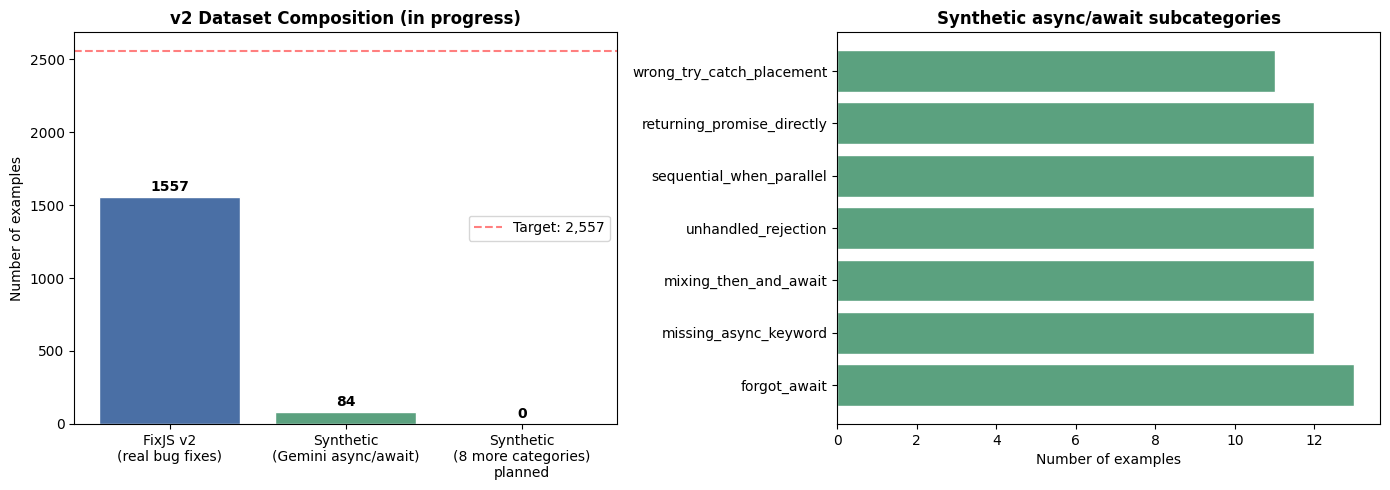

In [16]:
import matplotlib.pyplot as plt
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: source composition
sources = ['FixJS v2\n(real bug fixes)', 'Synthetic\n(Gemini async/await)', 'Synthetic\n(8 more categories)\nplanned']
counts = [
    v2_summary['fixjs_v2']['total_examples'],
    v2_summary['synthetic_async_await']['total_examples'],
    0  # planned categories, not yet generated
]
colors = ['#4A6FA5', '#5BA17F', '#C7C7C7']
axes[0].bar(sources, counts, color=colors, edgecolor='white')
axes[0].set_title('v2 Dataset Composition (in progress)', fontweight='bold')
axes[0].set_ylabel('Number of examples')
for i, v in enumerate(counts):
    axes[0].text(i, v + 40, str(v), ha='center', fontweight='bold')
axes[0].axhline(v2_summary['total_v2_target'], color='red', linestyle='--', alpha=0.5,
                label=f"Target: {v2_summary['total_v2_target']:,}")
axes[0].legend()

# Right: synthetic async/await subcategory distribution
subcats = v2_summary['synthetic_async_await']['subcategories']
axes[1].barh(list(subcats.keys()), list(subcats.values()),
             color='#5BA17F', edgecolor='white')
axes[1].set_title('Synthetic async/await subcategories', fontweight='bold')
axes[1].set_xlabel('Number of examples')

plt.tight_layout()
plt.savefig('/kaggle/working/v2_dataset_progress.png', dpi=120, bbox_inches='tight')
plt.show()

### v2 Pipeline Status and Next Steps

**Completed:**
- FixJS filtering pipeline producing 1,557 high-quality beginner-relevant examples (down from 13,330 in v1, prioritizing quality over quantity)
- Synthetic generation pipeline using Gemini API with structured output schema, syntax-validation, and per-batch quality control
- First synthetic category (async/await) at 84/200 examples, with 87% GOOD quality on stratified review

**In progress (this week):**
- Complete async/await synthetic generation (116 examples remaining)
- Generate 8 additional synthetic categories: let/const scope, arrow functions, destructuring, operator top-up, equality top-up, off-by-one top-up, array methods, template literals
- Manual quality review of full synthetic dataset

**Next:**
- Retrain Qwen2.5-Coder-7B on the v2 hybrid dataset
- Deploy retrained model to Together AI for the school pilot
- Add RAG component to inference pipeline using Supabase pgvector with MDN documentation and TVET curriculum content